## Task 2: Basic Probabilities and Visualizations (2)

The task requires analyzing the random variable $Y$, the time (in hours) until an owl is heard.

$\xi_{4} = 0,$

$\xi_5=0.29,$

$\xi_6=8,$

$\xi_7=0.70,$

$\xi_8=3$
 
Since $\xi_4 = 0$, we use the function: $$ R(y) = P(Y > y) = \xi_5e^{-\xi_6 y} + \xi_7e^{-\xi_8 y} $$ Substituting the parameter values: $\xi_5=0.29$, $\xi_6=8$, $\xi_7=0.70$, $\xi_8=3$. $$ \mathbf{R(y) = 0.29e^{-8y} + 0.70e^{-3y}} $$

________________
***Note on Constraint:*** The assignment requires that $\xi_5 + \xi_7 = 1$. 

The given parameters yield $0.29 + 0.70 = 0.99$.

We proceed using the given values, acknowledging that $R(0) = 0.99$, which is close to 1 but suggests a minor normalization inconsistency in the generated parameters.

________________

In [10]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.integrate import quad

**Step 1:**

Finding the PDF

Calculate $f(y)$ using the relationship $f(y) = F'(y) = -R'(y)$

The Cumulative Distribution Function (CDF) is $F(y) = P(Y \le y) = 1 - R(y)$ <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 23)</cite>.

The PDF $f(y)$ is the derivative of the CDF: $f(y) = F'(y) = -R'(y)$ <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 23)</cite>.

Mathematical Calculation: $$ R'(y) = \frac{d}{dy} (0.29e^{-8y} + 0.70e^{-3y}) $$ $$ R'(y) = 0.29(-8)e^{-8y} + 0.70(-3)e^{-3y} $$ $$ R'(y) = -2.32e^{-8y} - 2.10e^{-3y} $$ Therefore, the PDF is: $$ \mathbf{f(y) = 2.32e^{-8y} + 2.10e^{-3y}} \quad \text{for } y \ge 0 $$

In [11]:
# Define parameters
xi5, xi6, xi7, xi8 = 0.29, 8, 0.70, 3

# R(y): Remaining probability P(Y > y)
def R(y):
    return xi5 * np.exp(-xi6 * y) + xi7 * np.exp(-xi8 * y)

# f(y): Probability Density Function
def f(y):
    # f(y) = -R'(y)
    return (xi5 * xi6 * np.exp(-xi6 * y) +
            xi7 * xi8 * np.exp(-xi8 * y))

# CDF F(y): P(Y <= y)
def F(y):
    return 1 - R(y)


**Step 2:**

Calculating Waiting Probability

Find $P(2 \le Y \le 4)$, calculated as $R(2) - R(4)$

The probability of waiting between two and four hours is calculated using the CDF <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 26)</cite>: $$ P(2 \le Y \le 4) = F(4) - F(2) $$ Equivalently, using the remaining probability $R(y)$: $$ P(2 \le Y \le 4) = R(2) - R(4) $$


In [12]:
P_2_to_4 = R(2) - R(4)
print(f"P(Y > 2) = {R(2):.8f}")
print(f"P(Y > 4) = {R(4):.8f}")
print(f"P(2 <= Y <= 4) = R(2) - R(4) = {P_2_to_4:.8f}")

P(Y > 2) = 0.00173516
P(Y > 4) = 0.00000430
P(2 <= Y <= 4) = R(2) - R(4) = 0.00173086


**Step 3:**

Calculating Mean $E[Y]$

Computing $E[Y]$ using the continuous integral: $E[Y] = \int_0^\infty y f(y) dy$


The mean $E[Y]$ is calculated using $E[Y] = \int_0^\infty y f(y) dy$ <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 48, Eqn 2.6)</cite>. 

This is an integral of a mixture of two exponential components. For $A e^{-\lambda y}$, $\int_0^\infty y A e^{-\lambda y} dy = A/\lambda^2$.

Mathematical Calculation: $$ E[Y] = \frac{\xi_5 \xi_6}{\xi_6^2} + \frac{\xi_7 \xi_8}{\xi_8^2} = \frac{\xi_5}{\xi_6} + \frac{\xi_7}{\xi_8} $$ $$ E[Y] = \frac{0.29}{8} + \frac{0.70}{3} \approx 0.03625 + 0.23333 = \mathbf{0.269583} \text{ hours} $$


In [13]:
E_Y = (xi5 / xi6) + (xi7 / xi8)
E_Y2 = (2 * xi5 / xi6**2) + (2 * xi7 / xi8**2)
print(f"\nMean E[Y]: {E_Y:.4f} hours")


Mean E[Y]: 0.2696 hours


**Step 4:**

Calculating Variance $Var[Y]$

Computing $Var[Y] = E[Y^2] - (E[Y])^2$

The variance is $Var[Y] = E[Y^2] - (E[Y])^2$ (Chapter 2: 2.2, P. 57, Eqn 2.20). 

For $A e^{-\lambda y}$, $\int_0^\infty y^2 A e^{-\lambda y} dy = A \cdot \frac{2}{\lambda^3}$.

Mathematical Calculation: $$ E[Y^2] = \frac{\xi_5 \xi_6 \cdot 2}{\xi_6^3} + \frac{\xi_7 \xi_8 \cdot 2}{\xi_8^3} = \frac{2 \xi_5}{\xi_6^2} + \frac{2 \xi_7}{\xi_8^2} $$ $$ E[Y^2] = \frac{2 \cdot 0.29}{8^2} + \frac{2 \cdot 0.70}{3^2} \approx 0.0090625 + 0.155556 \approx 0.164618 $$ $$ Var[Y] = E[Y^2] - (E[Y])^2 \approx 0.164618 - (0.269583)^2 \approx \mathbf{0.09176} \text{ hours}^2 $$


In [14]:
Var_Y = E_Y2 - E_Y**2
Std_Y = np.sqrt(Var_Y)

print(f"Variance Var[Y]: {Var_Y:.6f} hours^2")

Variance Var[Y]: 0.091943 hours^2


**Step 5:**

Calculating Quartiles $Q_1, Q_2, Q_3$

Calculating quartiles by solving $R(y) = 1-q$ for $q \in {0.25, 0.5, 0.75}$

Quartiles $Q_q$ are solutions to $R(y) = 1 - q$, where $q \in {0.25, 0.50, 0.75}$ [U2: 2.1, P. 52]. 

This requires numerical root-finding.

In [15]:
# Function to find the roots (quartiles)
def find_quartile(q):
    # We seek y such that F(y) = q, or R(y) = 1 - q
    target = 1 - q
    # Define the equation f(y) = R(y) - target, whose root is the quartile
    equation = lambda y: R(y) - target

    # Use root_scalar to find the solution, starting search in the range
    result = root_scalar(equation, bracket=[0, 5], method='brentq')
    return result.root if result.converged else np.nan


Q1 = find_quartile(0.25)
Q2 = find_quartile(0.50) # Median
Q3 = find_quartile(0.75)


print(f"Q1: {Q1:.4f} hours")
print(f"Q2 (Median): {Q2:.4f} hours")
print(f"Q3: {Q3:.4f} hours")


Q1: 0.0645 hours
Q2 (Median): 0.1672 hours
Q3: 0.3648 hours


**Step 6**

Creating PDF Graph

We display the graph of $f(y)$ and mark the location of the calculated mean, variance (as standard deviation $\pm \sigma$), and quartiles. We plot the distribution from $y=0$ until $f(y)$ is negligible (e.g., $y=2$ hours, since $R(2) \approx 0.0004$).

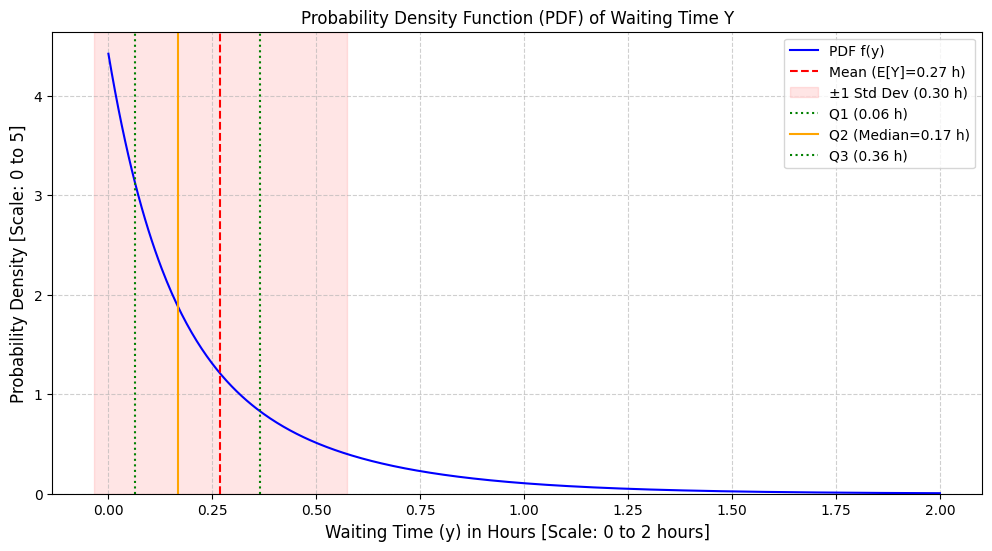

In [16]:
y_hours = np.linspace(0, 2, 500)
f_y = f(y_hours)

plt.figure(figsize=(12, 6))

# Plot the PDF
plt.plot(y_hours, f_y, label='PDF f(y)', color='blue')

# Mark Mean
plt.axvline(E_Y, color='red', linestyle='--', label=f'Mean (E[Y]={E_Y:.2f} h)')

# Mark Variance (using standard deviation)
plt.axvspan(E_Y - Std_Y, E_Y + Std_Y, color='red', alpha=0.1, label=f'±1 Std Dev ({Std_Y:.2f} h)')

# Mark Quartiles
plt.axvline(Q1, color='green', linestyle=':', label=f'Q1 ({Q1:.2f} h)')
plt.axvline(Q2, color='orange', linestyle='-', label=f'Q2 (Median={Q2:.2f} h)')
plt.axvline(Q3, color='green', linestyle=':', label=f'Q3 ({Q3:.2f} h)')

# Formatting (Required: Include Scale)
plt.title('Probability Density Function (PDF) of Waiting Time Y')
plt.xlabel('Waiting Time (y) in Hours [Scale: 0 to 2 hours]', fontsize=12)
plt.ylabel('Probability Density [Scale: 0 to 5]', fontsize=12)
plt.ylim(0, np.max(f_y) * 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Step 7**

Creating Histogram per Minutes

We must convert the continuous density $f(y)$ (hours) into discrete probabilities $P(Y \in [m/60, (m+1)/60])$ for each minute $m$.
We will discretize the interval $y \in [0, K_{min}/60]$ where $K_{min}$ is the number of minutes, choosing a range of 0 to 2 hours (120 minutes) as the probability has effectively vanished by then.
Unit Conversion and Discretization: Let $y_{start}$ and $y_{end}$ be the start and end of a 1-minute interval, in hours.

The probability for that minute is: $$ P(\text{minute}) = F(y_{end}) - F(y_{start}) = \int_{y_{start}}^{y_{end}} f(y) dy $$


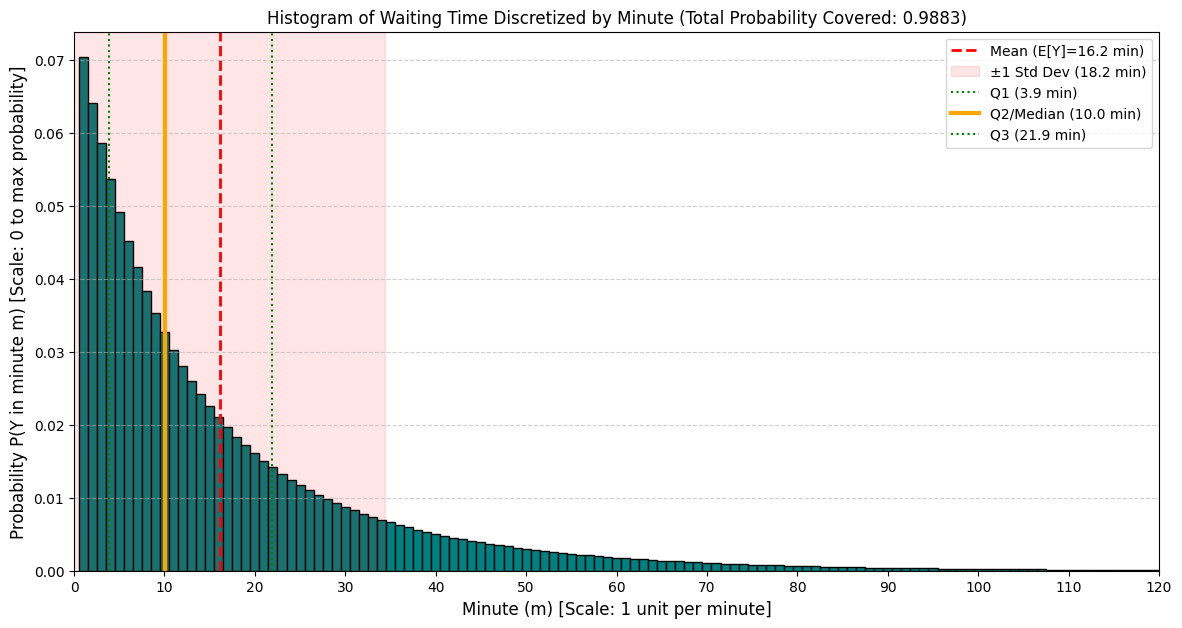

In [17]:
# Define the range in minutes (0 to 120 minutes = 2 hours)
num_minutes = 120
minutes = np.arange(1, num_minutes + 1)
probabilities_per_minute = []

for m in minutes:
    # Convert minute index to hours (y_end = m/60, y_start = (m-1)/60)
    y_end = m / 60.0
    y_start = (m - 1) / 60.0

    # Calculate the probability for this minute by integrating the PDF
    # Since the integral of f(y) is F(y) = 1 - R(y), we use the CDF definition:
    prob = F(y_end) - F(y_start)

    probabilities_per_minute.append(prob)

# We sum the discrete probabilities to verify coverage
total_prob_covered = np.sum(probabilities_per_minute)

# --- Visualization ---

# Convert location statistics to minutes for display
E_Y_min = E_Y * 60
M_min = Q2 * 60
Std_Y_min = Std_Y * 60
Q1_min = Q1 * 60
Q3_min = Q3 * 60

plt.figure(figsize=(14, 7))
plt.bar(minutes, probabilities_per_minute, width=1.0, color='teal', edgecolor='black')

# Mark Mean and Variance in minutes
plt.axvline(E_Y_min, color='red', linestyle='--', linewidth=2, label=f'Mean (E[Y]={E_Y_min:.1f} min)')
plt.axvspan(E_Y_min - Std_Y_min, E_Y_min + Std_Y_min, color='red', alpha=0.1, label=f'±1 Std Dev ({Std_Y_min:.1f} min)')

# Mark Quartiles in minutes
plt.axvline(Q1_min, color='green', linestyle=':', label=f'Q1 ({Q1_min:.1f} min)')
plt.axvline(M_min, color='orange', linestyle='-', linewidth=3, label=f'Q2/Median ({M_min:.1f} min)')
plt.axvline(Q3_min, color='green', linestyle=':', label=f'Q3 ({Q3_min:.1f} min)')


# Formatting (Required: Include Scale)
plt.title(f'Histogram of Waiting Time Discretized by Minute (Total Probability Covered: {total_prob_covered:.4f})')
plt.xlabel('Minute (m) [Scale: 1 unit per minute]', fontsize=12)
plt.ylabel('Probability P(Y in minute m) [Scale: 0 to max probability]', fontsize=12)
plt.xlim(0, num_minutes)
plt.xticks(np.arange(0, num_minutes + 1, 10))
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


**Step 8**

Final Summary of Calculated Statistics

In [18]:
# Final Summary of Calculated Statistics
print("\n--- Summary of Location and Dispersion Parameters ---")
print(f"Mean (E[Y]): {E_Y:.4f} hours ({E_Y_min:.1f} minutes)")
print(f"Variance (Var[Y]): {Var_Y:.6f} hours^2")
print(f"Q1: {Q1:.4f} hours ({Q1_min:.1f} minutes)")
print(f"Q2 (Median): {Q2:.4f} hours ({M_min:.1f} minutes)")
print(f"Q3: {Q3:.4f} hours ({Q3_min:.1f} minutes)")


--- Summary of Location and Dispersion Parameters ---
Mean (E[Y]): 0.2696 hours (16.2 minutes)
Variance (Var[Y]): 0.091943 hours^2
Q1: 0.0645 hours (3.9 minutes)
Q2 (Median): 0.1672 hours (10.0 minutes)
Q3: 0.3648 hours (21.9 minutes)


**Justification of Tools Used**

The computations for the expectation and variance were performed using explicit mathematical formulas derived from the integral definitions for mixed exponential distributions <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 48, 57)</cite>.

The implementation relies on NumPy for array manipulation and calculation. Matplotlib is used for plotting, ensuring clear scales and labels, as required by the assignment.

The calculation of the Quartiles requires solving transcendental equations ($R(y) = 1-q$), for which the numerical solver scipy.optimize.root_scalar is used.

These standard Python scientific computing libraries are considered reliable and trustworthy tools for statistical calculations.
